In [ ]:
!pip install pandas seaborn matplotlib numpy statsmodels

In [2]:
import json
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 1. Load the data from GrimoireLab and build a dataframe

with open('../data/metrics.json', 'r') as f:
    data = json.load(f)

records = []
for pkg, info in data['packages'].items():
    metrics = info.get('metrics', {})
    # metrics['package'] = pkg  # Keep the package name just in case
    records.append(metrics)

df = pd.DataFrame(records)



In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
total_commits,70.0,21.700000,87.396208,0.000000,0.000000,1.000000,21.000000,725.000000
total_contributors,70.0,3.114286,6.564160,0.000000,0.000000,1.000000,3.750000,47.000000
total_organizations,70.0,1.842857,3.407731,0.000000,0.000000,1.000000,2.000000,23.000000
pony_factor,70.0,0.714286,0.853685,0.000000,0.000000,1.000000,1.000000,5.000000
elephant_factor,70.0,0.628571,0.640910,0.000000,0.000000,1.000000,1.000000,2.000000
recent_organizations,70.0,0.885714,1.798090,0.000000,0.000000,0.000000,1.000000,10.000000
recent_contributors,70.0,1.257143,2.842155,0.000000,0.000000,0.000000,1.000000,17.000000
recent_commits,70.0,6.628571,27.268483,0.000000,0.000000,0.000000,2.000000,222.000000
contributor_growth,70.0,0.457143,4.379417,-8.000000,0.000000,0.000000,0.000000,32.000000
contributor_growth_rate,70.0,0.088735,0.862652,-1.000000,0.000000,0.000000,0.000000,4.000000


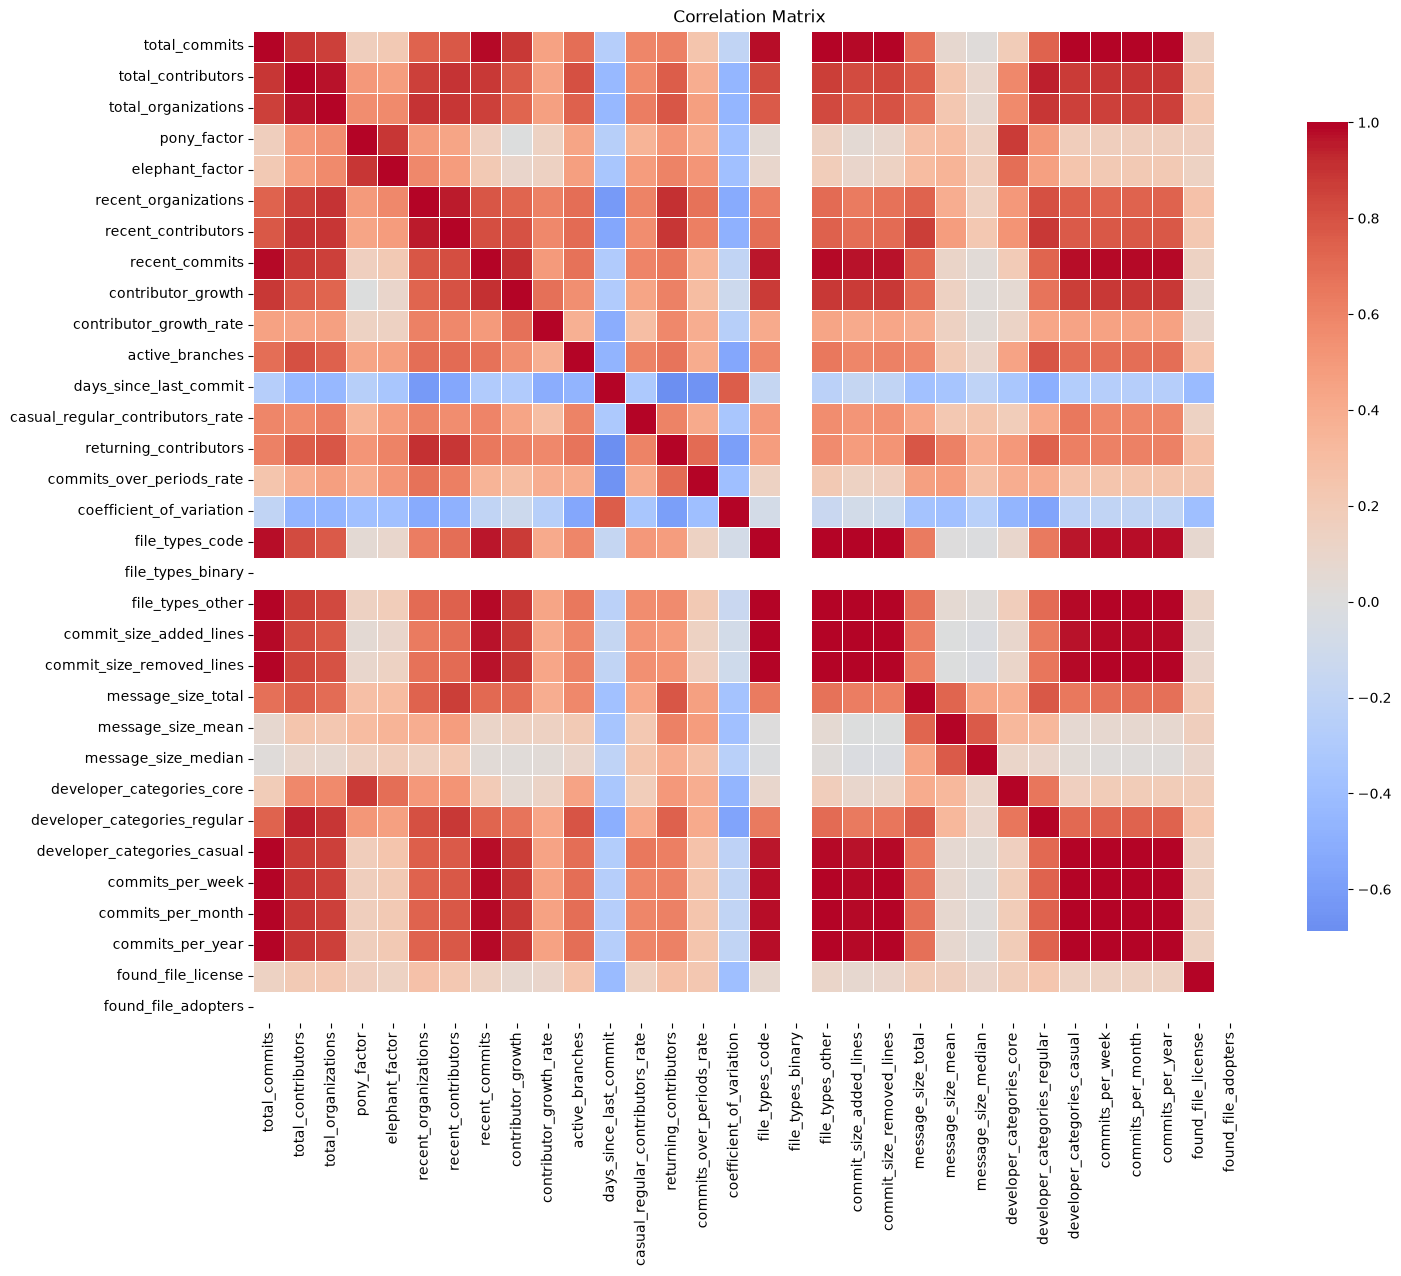

In [5]:
# 2. Data cleaning

corr = df.corr(method="pearson")

plt.figure(figsize=(16, 14))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": .75}
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Time to remove collinear or multicollinear features to simplify ther model, 
# reduce overfitting, and make the data more interpretable.

threshold = 0.8

corr_matrix = corr.abs()

# Create a mask to select the upper triangle of the matrix
# This prevents comparing a feature to itself or checking pairs twice (e.g., A vs B and B vs A)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = upper.columns[(upper > threshold).any()].tolist()
print(f"Features flagged for removal (correlation > {threshold}):\n{high_corr}")

df_low_corr = df.drop(columns=high_corr)

print(f"\nOriginal shape: {df_numeric.shape}")
print(f"New shape after removing correlated features: {df_low_corr.shape}")


Features flagged for removal (correlation > 0.8):
['total_contributors', 'total_organizations', 'elephant_factor', 'recent_organizations', 'recent_contributors', 'recent_commits', 'contributor_growth', 'active_branches', 'returning_contributors', 'file_types_code', 'file_types_other', 'commit_size_added_lines', 'commit_size_removed_lines', 'message_size_total', 'developer_categories_core', 'developer_categories_regular', 'developer_categories_casual', 'commits_per_week', 'commits_per_month', 'commits_per_year']


NameError: name 'df_numeric' is not defined

# Warning

We have it done, but "Correlation only detects pairwise relationships. Logistic regression is more affected by multicollinearity, which VIF measures."

But, since the end goal is prediction with logistic regression, we won't remove variables based on VIF alone. The recommendation is to:
 - Remove constant variables.
 - Remove perfectly redundant variables (e.g., counts that are exact sums of others).
 - Fit a regularized logistic regression (L1/Lasso or Elastic Net), which can handle correlated predictors by shrinking or eliminating less informative ones. Comparing the performance of a regularized model to a manually reduced feature set is often more informative than relying solely on VIF.

In [ ]:
metric_names = pd.Series(df_low_corr.columns, name="metric_name")

# Save just the names to a CSV
output_file = 'low_correlated_metric_names.csv'
metric_names.to_csv(output_file, index=False)

print(f"Successfully saved {len(metric_names)} metric names to '{output_file}'!")
print(list(df_low_corr.columns))

In [ ]:
# https://stats.stackexchange.com/questions/271954/vifcollinearity-vs-correlation
# https://www.graphpad.com/guides/prism/latest/curve-fitting/reg_multiple_logistic_results_multicollinearity.htm

from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(df):
    return pd.DataFrame({
        "Variable": df.columns,
        "VIF": [
            variance_inflation_factor(df.values, i)
            for i in range(df.shape[1])
        ]
    }).sort_values("VIF", ascending=False)

X = df_numeric.drop(columns=[
    "file_types_binary",
    "found_file_adopters"
]).fillna(0)

while True:
    vif = calculate_vif(X)

    max_vif = vif.iloc[0]["VIF"]

    if max_vif < 10:
        break

    feature = vif.iloc[0]["Variable"]

    print(f"Removing {feature} (VIF={max_vif:.2f})")

    X = X.drop(columns=feature)

calculate_vif(X)